In [69]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [70]:
# Load Dataset
df = pd.read_csv("dataset/german_credit_data.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [71]:
df.shape

(1000, 11)

In [72]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [74]:
df.describe(include="all")

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.500000,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,249.750000,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,499.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,749.250000,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


In [75]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [76]:
df["Saving accounts"] = df["Saving accounts"].fillna("Unknown")
df["Checking account"] = df["Checking account"].fillna("Unknown")

df.isnull().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [77]:
df.drop("Unnamed: 0", axis=1, inplace=True)

df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,Unknown,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,Unknown,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [78]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "Sex",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Purpose",
    "Risk"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,1,1169,6,5,1
1,22,0,2,1,1,2,5951,48,5,0
2,49,1,1,1,1,0,2096,12,3,1
3,45,1,2,0,1,1,7882,42,4,1
4,53,1,2,0,1,1,4870,24,1,0


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   int64
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   int64
 4   Saving accounts   1000 non-null   int64
 5   Checking account  1000 non-null   int64
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   int64
 9   Risk              1000 non-null   int64
dtypes: int64(10)
memory usage: 78.3 KB


In [80]:
df["Risk"].value_counts()

Risk
1    700
0    300
Name: count, dtype: int64

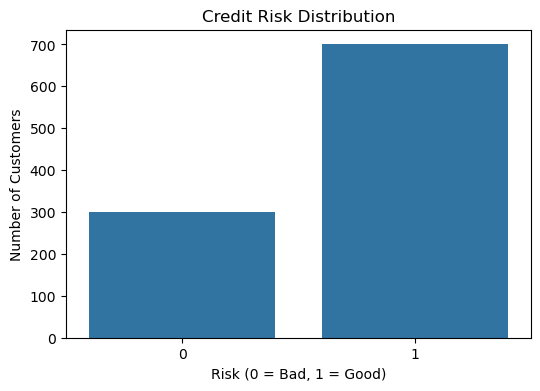

In [81]:
plt.figure(figsize=(6,4))

sns.countplot(x="Risk", data=df)

plt.title("Credit Risk Distribution")
plt.xlabel("Risk (0 = Bad, 1 = Good)")
plt.ylabel("Number of Customers")

plt.savefig("images/risk_distribution.png")
plt.show()

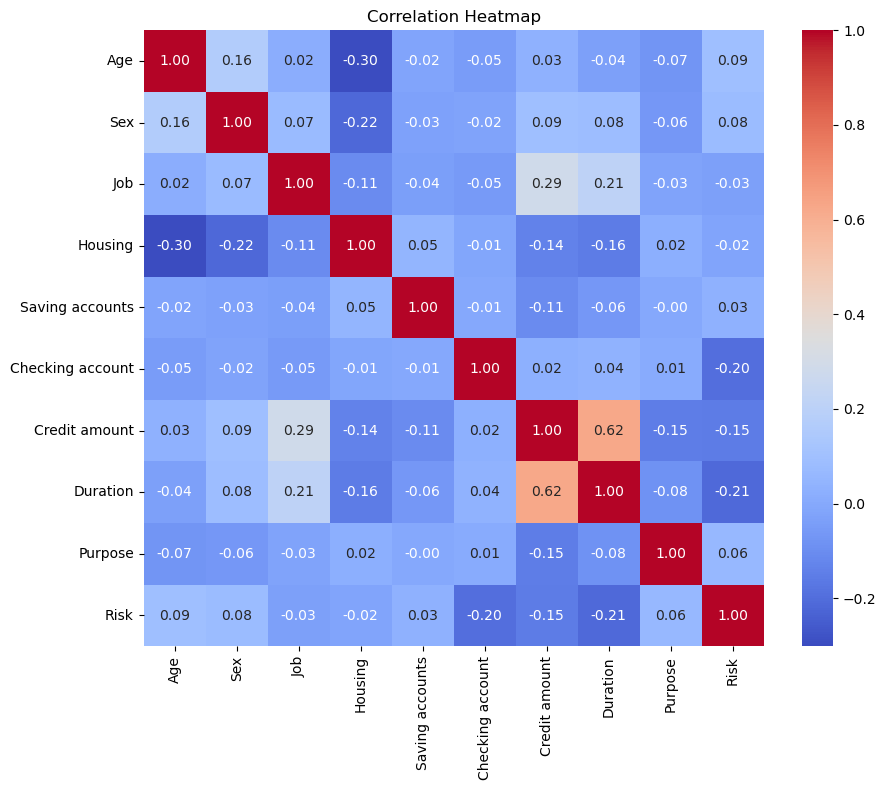

In [82]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("images/correlation_heatmap.png")
plt.show()

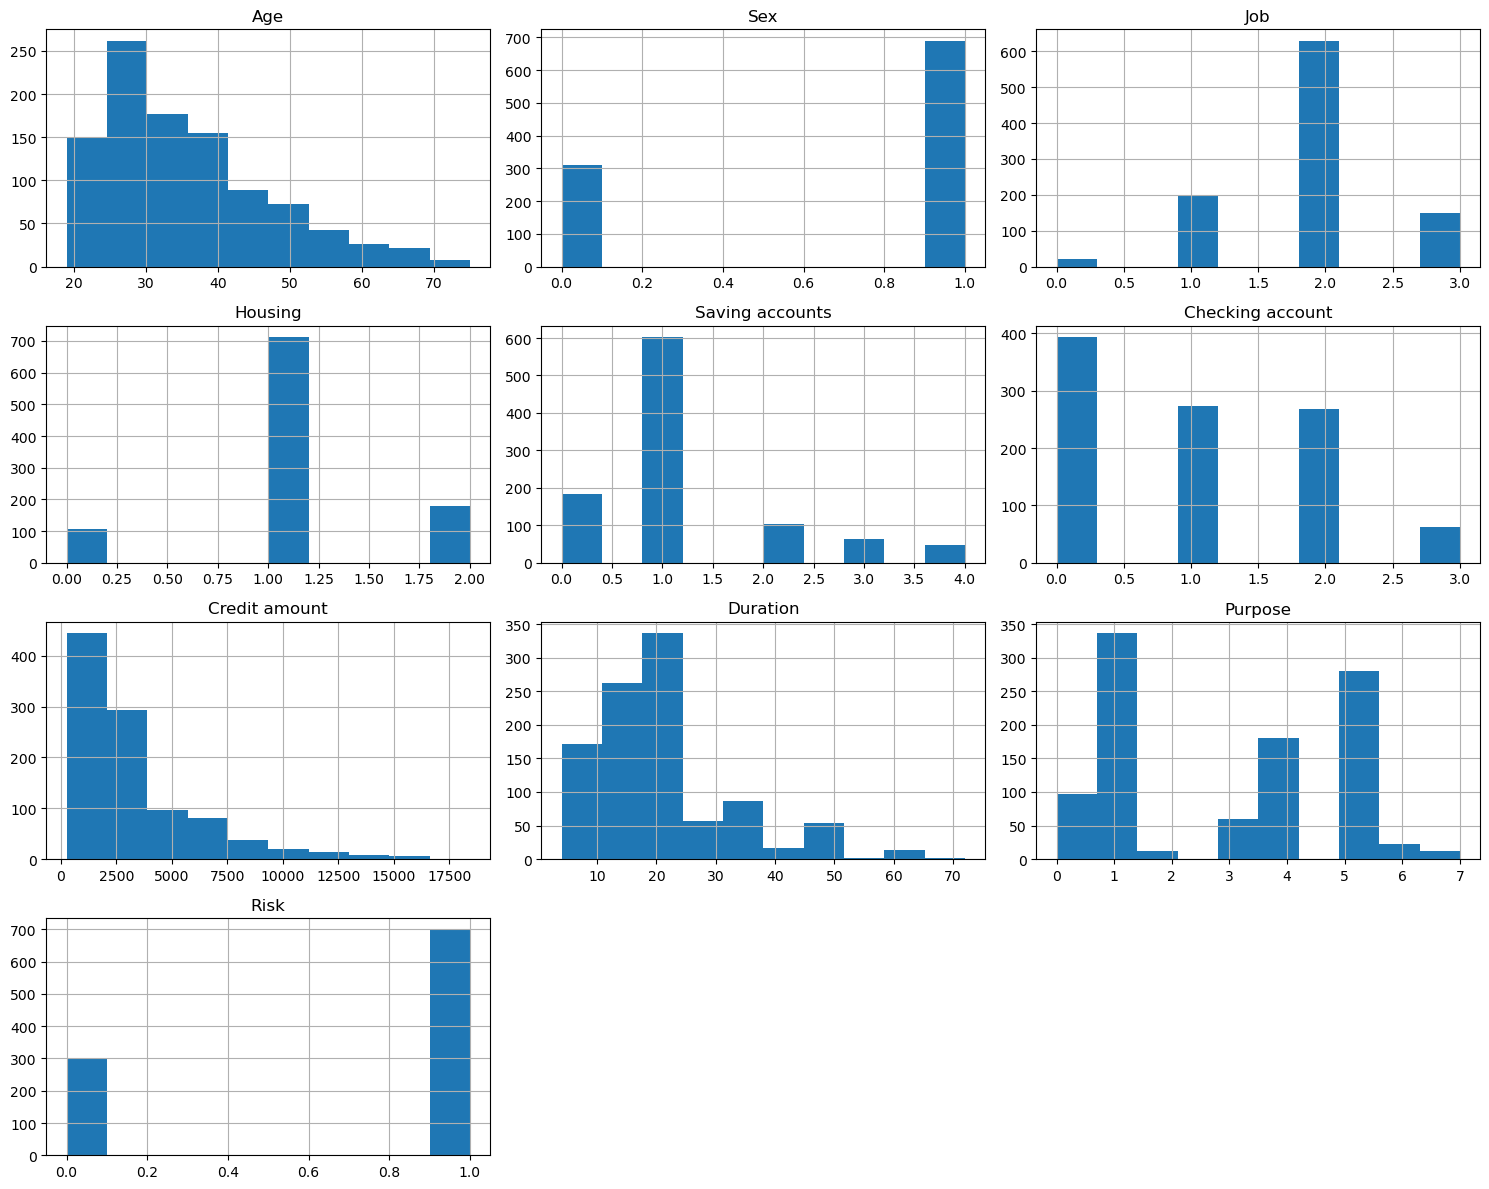

In [83]:
df.hist(figsize=(15,12))

plt.tight_layout()

plt.savefig("images/histograms.png")
plt.show()

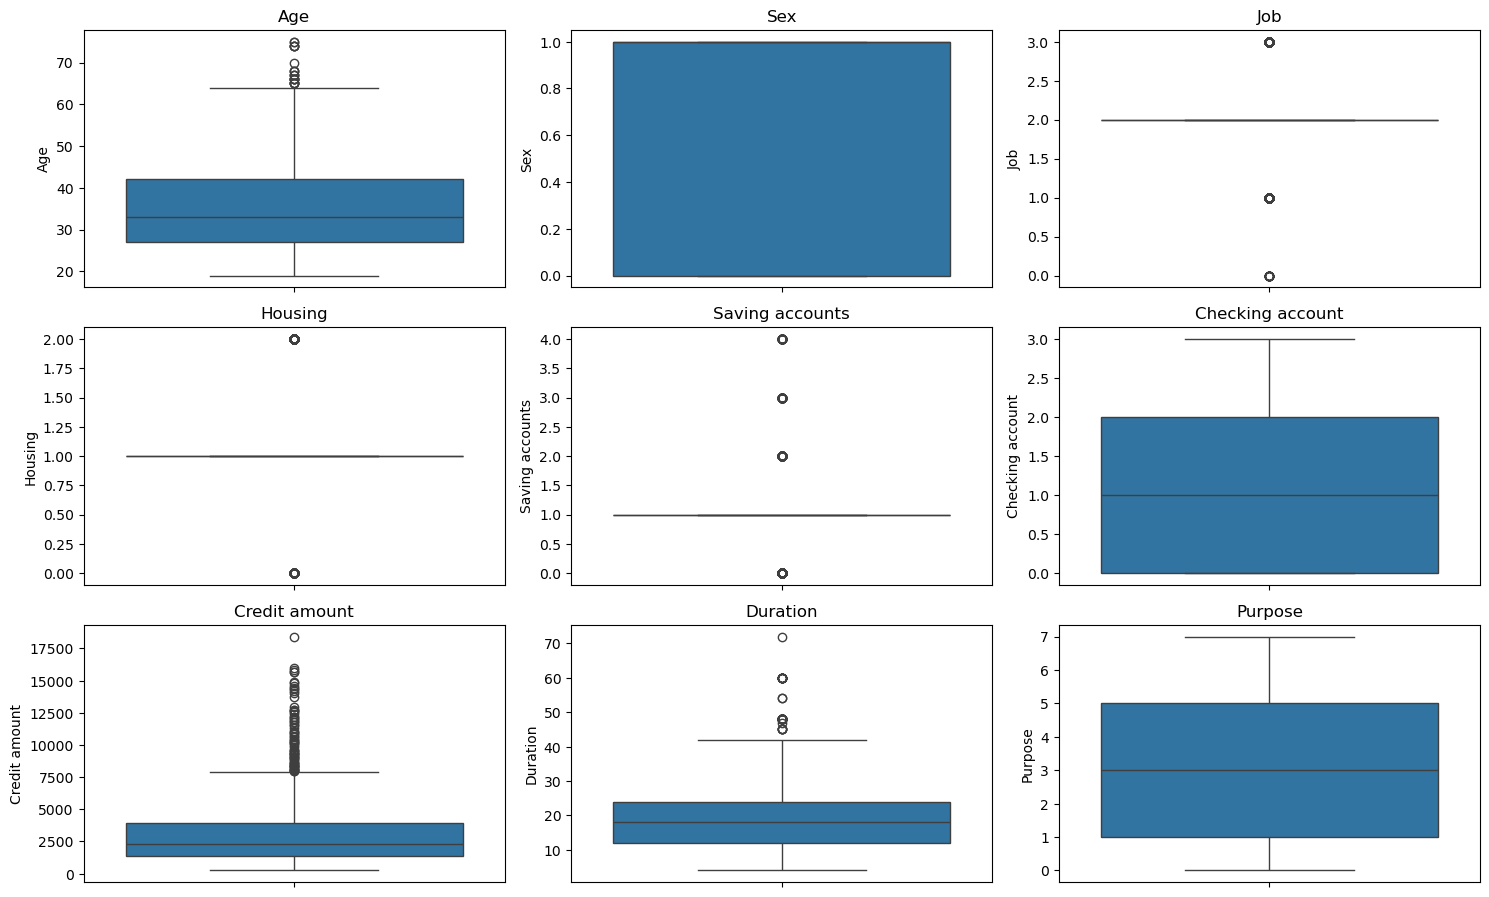

In [84]:
plt.figure(figsize=(15,12))

for i, col in enumerate(df.columns[:-1]):
    plt.subplot(4,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()

plt.savefig("images/boxplots.png")
plt.show()

In [85]:
# Feature Engineering
df["Credit_per_Month"] = df["Credit amount"] / df["Duration"]

df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Credit_per_Month
0,67,1,2,1,0,1,1169,6,5,1,194.833333
1,22,0,2,1,1,2,5951,48,5,0,123.979167
2,49,1,1,1,1,0,2096,12,3,1,174.666667
3,45,1,2,0,1,1,7882,42,4,1,187.666667
4,53,1,2,0,1,1,4870,24,1,0,202.916667


In [86]:
X = df.drop("Risk", axis=1)
y = df["Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [87]:
#LOGISTIC REGRESSION MODEL
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [88]:
#DECISION TREE MODEL
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [89]:
#RANDOM FOREST MODEL
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [90]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

def evaluate_model(name, y_test, pred):

    print("="*50)
    print(name)
    print("="*50)

    print(f"Accuracy : {accuracy_score(y_test, pred)*100:.2f}%")
    print(f"Precision: {precision_score(y_test, pred)*100:.2f}%")
    print(f"Recall   : {recall_score(y_test, pred)*100:.2f}%")
    print(f"F1 Score : {f1_score(y_test, pred)*100:.2f}%")
    print()

In [91]:
evaluate_model("Logistic Regression", y_test, lr_pred)

evaluate_model("Decision Tree", y_test, dt_pred)

evaluate_model("Random Forest", y_test, rf_pred)  #best model

Logistic Regression
Accuracy : 70.50%
Precision: 72.28%
Recall   : 94.33%
F1 Score : 81.85%

Decision Tree
Accuracy : 73.50%
Precision: 81.88%
Recall   : 80.14%
F1 Score : 81.00%

Random Forest
Accuracy : 75.00%
Precision: 78.26%
Recall   : 89.36%
F1 Score : 83.44%



In [92]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, lr_pred))

print("Decision Tree")
print(classification_report(y_test, dt_pred))

print("Random Forest")
print(classification_report(y_test, rf_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.50      0.14      0.21        59
           1       0.72      0.94      0.82       141

    accuracy                           0.70       200
   macro avg       0.61      0.54      0.52       200
weighted avg       0.66      0.70      0.64       200

Decision Tree
              precision    recall  f1-score   support

           0       0.55      0.58      0.56        59
           1       0.82      0.80      0.81       141

    accuracy                           0.73       200
   macro avg       0.68      0.69      0.69       200
weighted avg       0.74      0.73      0.74       200

Random Forest
              precision    recall  f1-score   support

           0       0.62      0.41      0.49        59
           1       0.78      0.89      0.83       141

    accuracy                           0.75       200
   macro avg       0.70      0.65      0.66       200
weighted avg       0.73   

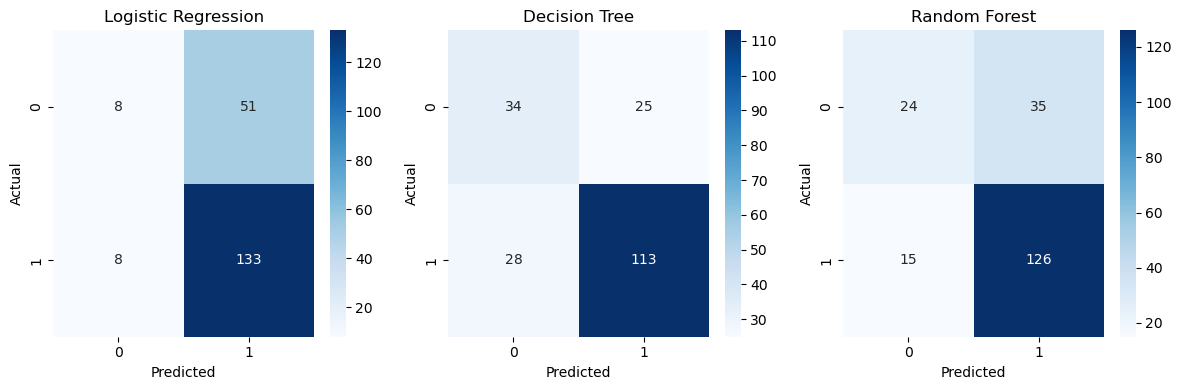

In [93]:
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

plt.figure(figsize=(12,4))

for i, (name, pred) in enumerate(models.items()):
    plt.subplot(1,3,i+1)

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("images/confusion_matrix.png")
plt.show()

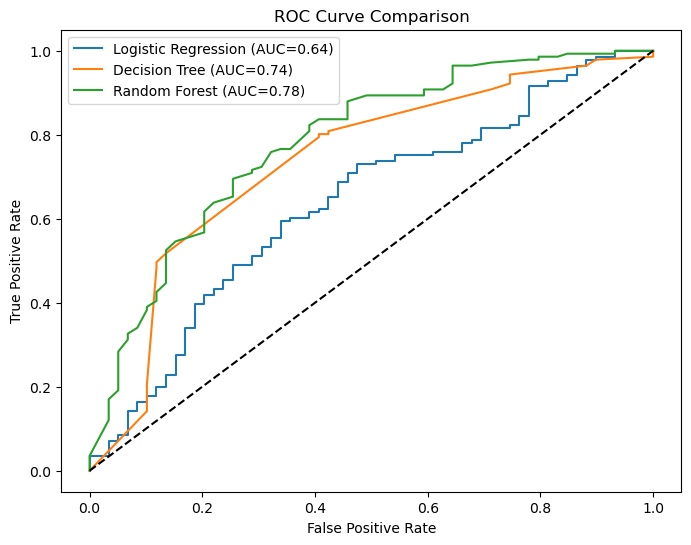

In [94]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig("images/roc_curve.png")
plt.show()

In [95]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy (%)":[
        round(accuracy_score(y_test, lr_pred)*100,2),
        round(accuracy_score(y_test, dt_pred)*100,2),
        round(accuracy_score(y_test, rf_pred)*100,2)
    ]
})

results

,Model,Accuracy (%)
0,Logistic Regression,70.5
1,Decision Tree,73.5
2,Random Forest,75.0


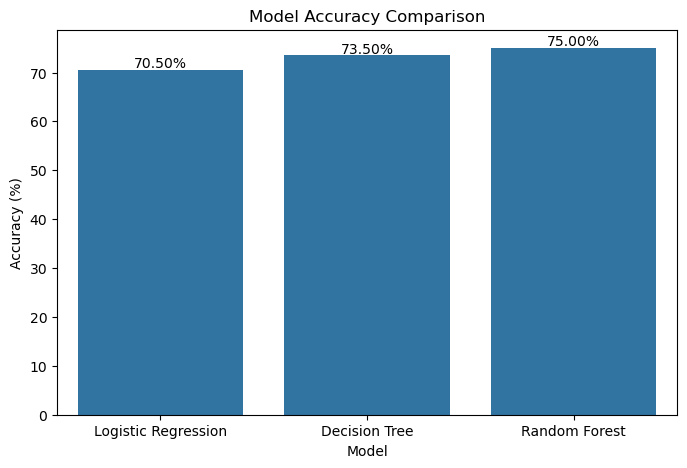

In [96]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=results,
    x="Model",
    y="Accuracy (%)"
)

for i, value in enumerate(results["Accuracy (%)"]):
    ax.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

plt.savefig("images/accuracy_comparison.png")
plt.show()